In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/Hamza-Taher/Machine-Intelligence-Project/main/nba_preprocessed.csv'
df = pd.read_csv(url)
print(df.shape)

(9067, 11)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [3]:
#LOAD DATA
url = 'https://raw.githubusercontent.com/Hamza-Taher/Machine-Intelligence-Project/main/nba_preprocessed.csv'
df = pd.read_csv(url)

print("Shape:", df.shape)
print(df.head())

Shape: (9067, 11)
   Game_Date  Team  Player        MP       PTS       TRB       AST       FGA  \
0   20251101    25     113  1.830533  2.048740 -0.015845  0.208047  1.805808   
1   20251101    25     494  1.582544  2.273030 -0.015845 -0.177476  1.470112   
2   20251101    25     117  1.418808  1.488015  0.283463  1.750142  0.798719   
3   20251101    25     127  1.404501  1.488015  2.677930  1.364618  0.798719   
4   20251101    25     143 -1.636546 -0.979176 -0.913770 -0.948523 -1.215461   

        FG%      STL       TOV  
0  0.293646 -0.78218  0.508793  
1  0.059664  0.22981 -0.910007  
2  0.672273  1.24180  1.218193  
3  0.672273  0.22981  1.218193  
4  2.310152 -0.78218 -0.910007  


In [4]:
# PREPARE FEATURES AND TARGET
feature_cols = ['MP', 'PTS', 'TRB', 'AST', 'FGA', 'FG%', 'STL', 'TOV']
X = df[feature_cols]
y = df['Team']

print("Number of classes:", y.nunique())

Number of classes: 30


In [5]:
# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])

Train size: 7253
Test size:  1814


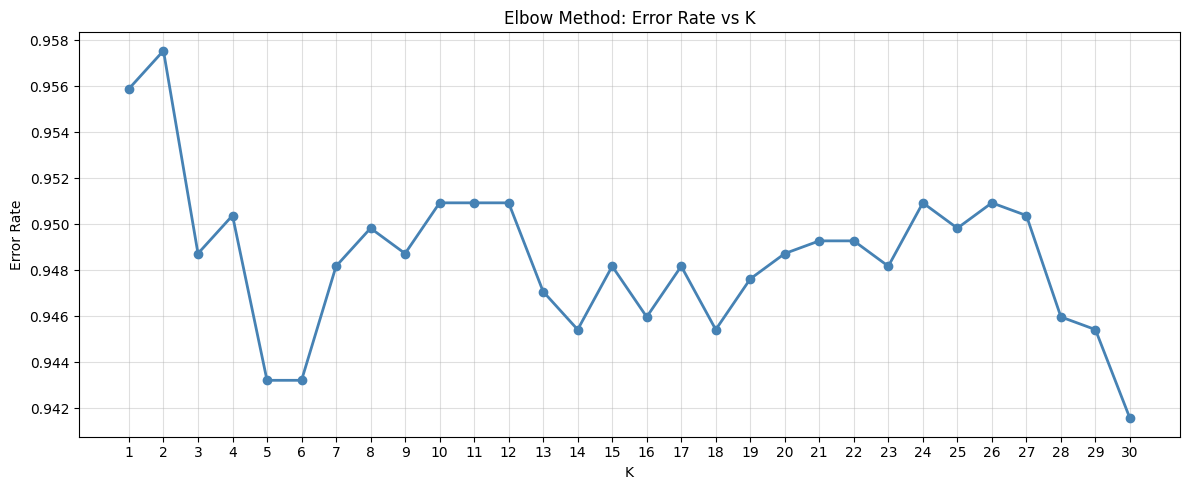

Best K: 30


In [6]:
#FIND BEST K (ELBOW METHOD)
error_rates = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, preds))

plt.figure(figsize=(12, 5))
plt.plot(k_range, error_rates, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method: Error Rate vs K')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmin(error_rates)]
print("Best K:", best_k)

In [7]:
#TRAIN KNN WITH BEST K
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='uniform'
)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [8]:
#EVALUATION
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")

cv_scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
print(f"Cross-Validation Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.0584 (5.84%)
Cross-Validation Mean: 0.0518 +/- 0.0023

Classification Report:
              precision    recall  f1-score   support

           0       0.07      0.12      0.09        58
           1       0.03      0.05      0.04        56
           2       0.07      0.11      0.08        54
           3       0.05      0.08      0.06        61
           4       0.13      0.18      0.15        60
           5       0.04      0.06      0.05        63
           6       0.05      0.06      0.05        63
           7       0.06      0.07      0.07        57
           8       0.01      0.02      0.01        62
           9       0.00      0.00      0.00        64
          10       0.08      0.07      0.07        56
          11       0.08      0.10      0.09        70
          12       0.05      0.03      0.04        58
          13       0.05      0.04      0.04        54
          14       0.08      0.07      0.07        58
          15       0.09      0.09      0.09  

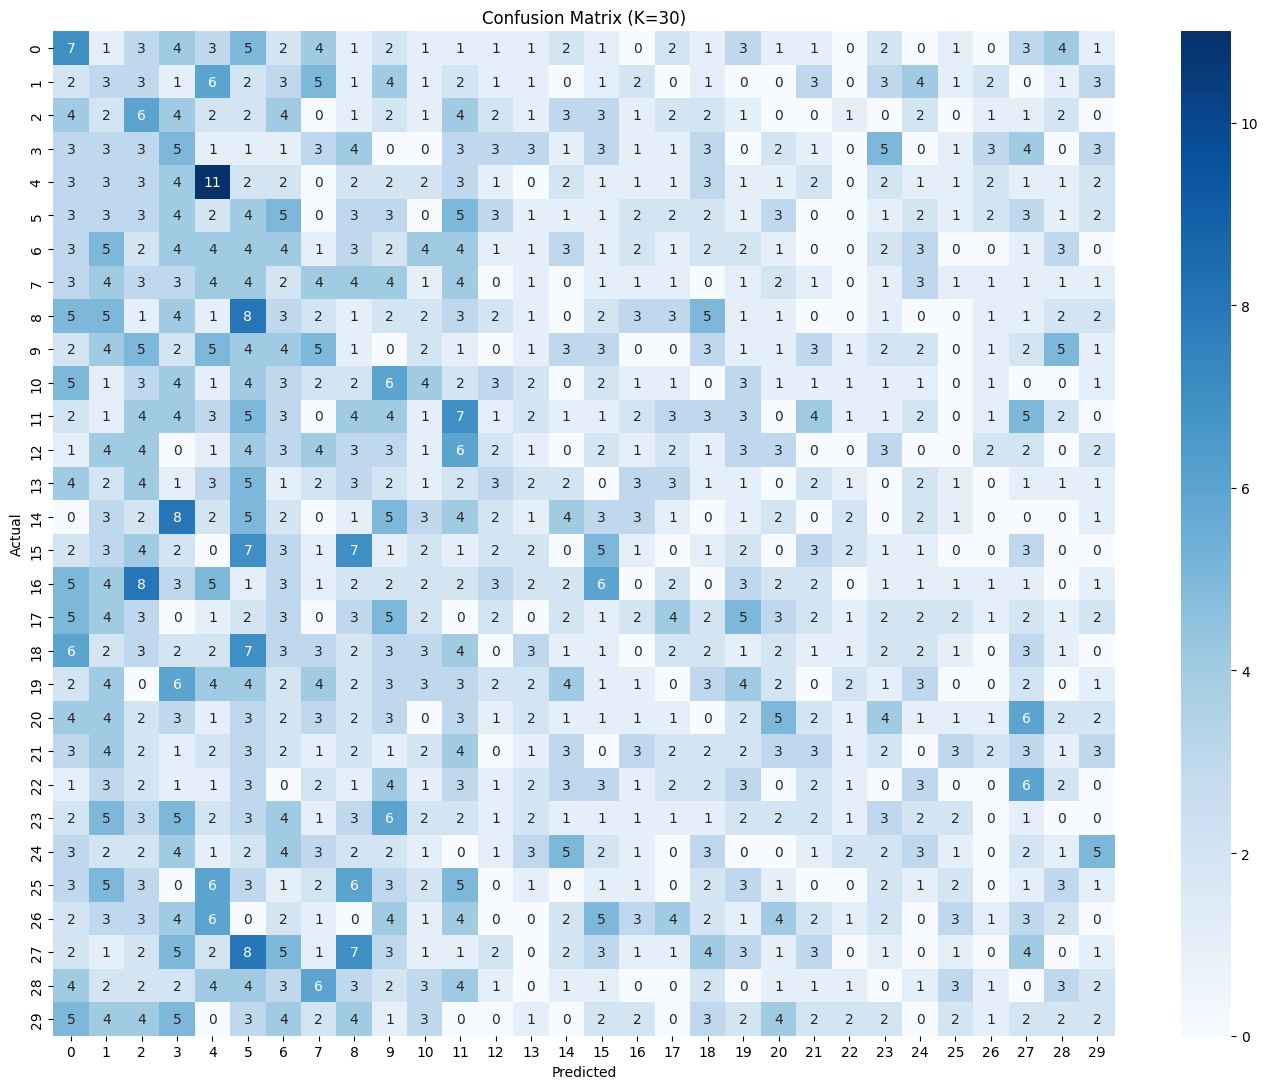

In [9]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)

plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title(f'Confusion Matrix (K={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

 K  Accuracy
 1    0.0441
 3    0.0513
 5    0.0568
 7    0.0518
 9    0.0513
11    0.0491
15    0.0518
30    0.0584


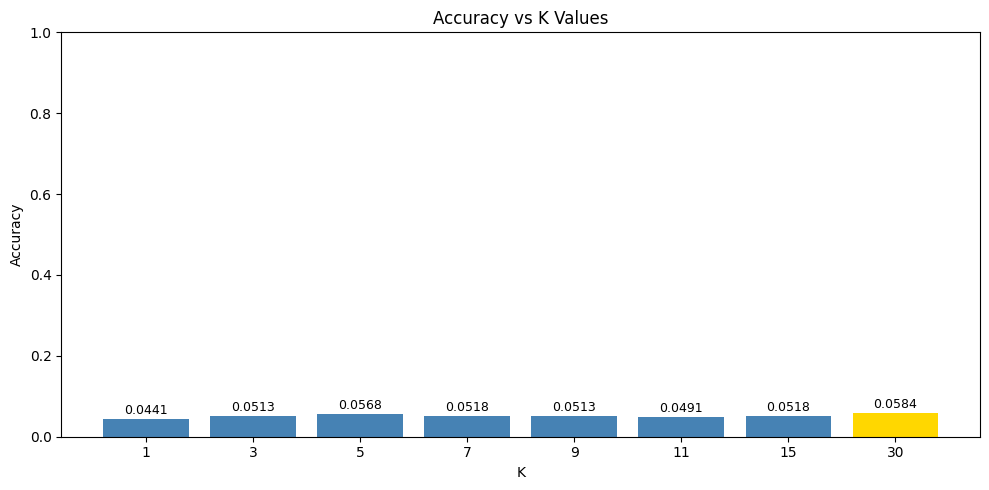

In [10]:
#ACCURACY COMPARISON ACROSS K VALUES
k_values = sorted(set([1, 3, 5, 7, 9, 11, 15, best_k]))
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    a = accuracy_score(y_test, model.predict(X_test))
    results.append({'K': k, 'Accuracy': round(a, 4)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['gold' if k == best_k else 'steelblue' for k in results_df['K']]
bars = plt.bar(results_df['K'].astype(str), results_df['Accuracy'], color=colors)
for bar, val in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             str(val), ha='center', va='bottom', fontsize=9)
plt.title('Accuracy vs K Values')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()